In [1]:
from flash_ansr import FlashANSR, SoftmaxSamplingConfig, BeamSearchConfig, MCTSGenerationConfig, install_model, get_path
 
import torch
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
MODEL = "v23.0-120M"

In [3]:
from flash_ansr.expressions.skeleton_pool import SkeletonPool
from flash_ansr.expressions.compilation import codify
from flash_ansr.expressions.token_ops import identify_constants
from flash_ansr.utils.tensor_ops import pad_input_set
from tqdm import tqdm

nsr = FlashANSR.load(
    directory=get_path('models', 'ansr-models', MODEL),
    generation_config=SoftmaxSamplingConfig(choices=1024 * 32),
    prune_constant_budget=0
).to(device)

# Load the skeleton pool from the training config to get the sampling priors
skeleton_pool = SkeletonPool.from_config(get_path('configs', MODEL, 'skeleton_pool_train.yaml'))
print(f"Skeleton pool: {skeleton_pool.n_variables} variables, {len(skeleton_pool.variables)} variable tokens")

Compiling Skeletons: 100%|██████████| 107/107 [00:00<00:00, 23441.66it/s]

Skeleton pool: 17 variables, 17 variable tokens


In [4]:
X = np.random.uniform(-10, 10, size=(1024, 1))

def fn(X):
    return ((0.2 + 0.01 * np.sin(X[:, 0] * 5)) * X[:, 0] + 2.5 * np.exp(-(X[:, 0] + 3.1) ** 2 / 0.5) - X[:, 0]**2 * 0.01) / (1 + np.sin(X[:, 0] * 0.5) * 0.5)

y = fn(X)

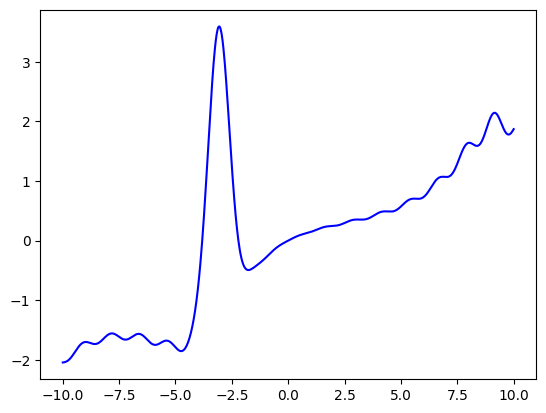

In [5]:
fig, ax = plt.subplots()

x_linspace = np.linspace(-10, 10, 1000).reshape(-1, 1)
y_linspace = fn(x_linspace)
ax.plot(x_linspace, y_linspace, label='True Function', color='blue')

In [6]:
nsr.fit(X, y, verbose=True)

Fitting Constants: 100%|██████████| 13461/13461 [01:48<00:00, 124.20it/s]


In [7]:
nsr.results

,log_prob,fvu,score,expression,constant_count,complexity,requested_complexity,raw_beam,beam,raw_beam_decoded,function,refiner,prompt_metadata,pruned_variant,beam_id,fit_constants,fit_covariances,fit_loss
0,-22.445438,0.064605,-0.539733,"[*, x1, -, /, cos, *, <constant>, x1, cosh, -,...",3,13,None,"[1, 9, 30, 66, 29, 31, 45, 30, 6, 66, 51, 29, ...","[30, 66, 29, 31, 45, 30, 6, 66, 51, 29, 66, 6, 6]","[*, x1, -, /, cos, *, <constant>, x1, cosh, -,...",<function <lambda> at 0x749c3272a7a0>,"Refiner(expression=['*', 'x1', '-', '/', 'cos'...","{'allowed_terms': [], 'include_terms': [], 'ex...",False,0,"[-1.1245328940162886, -3.1048722993914764, -0....","[[1.4272485515980098e-05, 2.2712702881519967e-...",0.108796
1,-19.032066,0.089288,-0.449208,"[*, x1, -, tan, /, cos, x1, cosh, +, <constant...",2,12,None,"[1, 9, 30, 66, 29, 46, 31, 45, 66, 51, 28, 6, ...","[30, 66, 29, 46, 31, 45, 66, 51, 28, 6, 66, 6]","[*, x1, -, tan, /, cos, x1, cosh, +, <constant...",<function <lambda> at 0x749c32282980>,"Refiner(expression=['*', 'x1', '-', 'tan', '/'...","{'allowed_terms': [], 'include_terms': [], 'ex...",False,1,"[2.5657064737281625, -0.1982759579102155]","[[0.000363427082357359, -4.144989016115141e-06...",0.150362
2,-25.488529,0.035558,-0.399064,"[/, x1, -, <constant>, *, +, <constant>, +, x1...",5,21,None,"[1, 9, 31, 66, 29, 6, 30, 28, 6, 28, 66, 49, 6...","[31, 66, 29, 6, 30, 28, 6, 28, 66, 49, 66, 31,...","[/, x1, -, <constant>, *, +, <constant>, +, x1...",<function <lambda> at 0x749c2ee1bb00>,"Refiner(expression=['/', 'x1', '-', '<constant...","{'allowed_terms': [], 'include_terms': [], 'ex...",False,2,"[1.2111883426749364, 4.620139999516056, 3.4774...","[[0.000263685920209615, 7.192747761571608e-05,...",0.059880
3,-43.285412,0.020989,-0.327999,"[/, +, x1, *, pow2, x1, /, *, <constant>, -, <...",7,27,None,"[1, 9, 31, 28, 66, 30, 36, 66, 31, 30, 6, 29, ...","[31, 28, 66, 30, 36, 66, 31, 30, 6, 29, 6, 45,...","[/, +, x1, *, pow2, x1, /, *, <constant>, -, <...",<function <lambda> at 0x749d4b870900>,"Refiner(expression=['/', '+', 'x1', '*', 'pow2...","{'allowed_terms': [], 'include_terms': [], 'ex...",False,3,"[5.099194071508758, -0.5097657687926713, -1.03...","[[0.0296419067958776, -0.0018825476790719539, ...",0.035347
4,-29.601915,0.039105,-0.307770,"[/, -, x1, /, pow2, x1, *, -, <constant>, cos,...",5,22,None,"[1, 9, 31, 29, 66, 31, 36, 66, 30, 29, 6, 45, ...","[31, 29, 66, 31, 36, 66, 30, 29, 6, 45, 29, 6,...","[/, -, x1, /, pow2, x1, *, -, <constant>, cos,...",<function <lambda> at 0x749d584d85e0>,"Refiner(expression=['/', '-', 'x1', '/', 'pow2...","{'allowed_terms': [], 'include_terms': [], 'ex...",False,4,"[-1.817700711993776, -7.7226922458517455, 4.01...","[[0.0013738330202844712, 0.0001045871000381151...",0.065853
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13102,-49.933052,NaN,NaN,"[*, x1, cos, exp, /, exp, *, <constant>, x1, -...",2,20,None,"[1, 9, 30, 66, 45, 56, 31, 56, 30, 6, 66, 29, ...","[30, 66, 45, 56, 31, 56, 30, 6, 66, 29, 66, 30...","[*, x1, cos, exp, /, exp, *, <constant>, x1, -...",<function <lambda> at 0x749d05eee160>,"Refiner(expression=['*', 'x1', 'cos', 'exp', '...","{'allowed_terms': [], 'include_terms': [], 'ex...",False,13102,"[1.9460458292386287, 2.1283040819715495]","[[inf, inf], [inf, inf]]",NaN
13103,-51.125736,NaN,NaN,"[*, <constant>, *, -, x1, <constant>, /, x1, -...",8,29,None,"[1, 9, 30, 6, 30, 29, 66, 6, 31, 66, 29, 66, 2...","[30, 6, 30, 29, 66, 6, 31, 66, 29, 66, 28, 6, ...","[*, <constant>, *, -, x1, <constant>, /, x1, -...",<function <lambda> at 0x749d05de1440>,"Refiner(expression=['*', '<constant>', '*', '-...","{'allowed_terms': [], 'include_terms': [], 'ex...",False,13103,"[4.643093590764463, -5.13167751994866, -2.9639...","[[inf, inf, inf, inf, inf, inf, inf, inf], [in...",NaN
13104,-51.041378,NaN,NaN,"[/, -, x1, *, <constant>, *, pow2, x1, /, cos,...",6,30,None,"[1, 9, 31, 29, 66, 30, 6, 30, 36, 66, 31, 45, ...","[31, 29, 66, 30, 6, 30, 36, 66, 31, 45, 29, 30..."

In [10]:
import pandas as pd


def eigenspectrum_entropy(
    embeddings: torch.Tensor,   # (n, d)
    eps: float = 1e-12,
    normalize: bool = True,
) -> float:
    """
    Compute eigenspectrum entropy for a single set of embeddings.
    Returns a scalar entropy value.
    """
    n = embeddings.shape[0]

    # Center
    centered = embeddings - embeddings.mean(dim=0, keepdim=True)  # (n, d)

    # SVD on CPU to avoid GPU memory pressure
    s = torch.linalg.svdvals(centered.cpu())  # (min(n, d),)

    eigvals = (s ** 2) / (n - 1)
    eigvals = eigvals.clamp(min=eps)

    p = eigvals / eigvals.sum()
    H = -torch.sum(p * torch.log(p)).item()

    if normalize:
        effective_rank = (eigvals > eps).sum().float()
        max_H = torch.log(effective_rank).item()
        H = H / max(max_H, 1e-12)

    return H


def add_specificity(
    results_df: pd.DataFrame,
    nsr: FlashANSR,
    skeleton_pool: SkeletonPool,
    K: int = 32,
    n_support: int = 1024,
) -> pd.DataFrame:
    """
    Augment a results DataFrame with a 'specificity' column.

    For each unique skeleton, batch-sample K datasets, encode them with the
    frozen SetTransformer, then compute eigenspectrum entropy of the
    embeddings. Low entropy = specific skeleton, high entropy = generic.

    Specificity is defined as 1 - normalized_entropy  (range [0, 1]).

    Entropy is computed per-skeleton to avoid accumulating all embeddings
    in memory at once.

    Parameters
    ----------
    results_df : pd.DataFrame
        The nsr.results DataFrame (must have an 'expression' column).
    nsr : FlashANSR
        A fitted FlashANSR instance.
    skeleton_pool : SkeletonPool
        The skeleton pool used for sampling data.
    K : int
        Number of datasets to sample per skeleton.
    n_support : int
        Number of support points per sampled dataset.

    Returns
    -------
    pd.DataFrame
        The input DataFrame with an added 'specificity' column.
    """
    simplipy = nsr.simplipy_engine
    model = nsr.flash_ansr_model
    n_vars = nsr.n_variables
    dev = next(model.parameters()).device
    model.eval()

    unique_exprs = results_df['expression'].apply(tuple).unique()
    specificity_cache: dict[tuple, float] = {}

    with torch.no_grad():
        for expr_tuple in tqdm(unique_exprs, desc="Computing specificity"):
            tokens = list(expr_tuple)
            try:
                executable = simplipy.operators_to_realizations(tokens)
                expr_with_consts, consts = identify_constants(executable, inplace=True)
                code_str = simplipy.prefix_to_infix(expr_with_consts, realization=True)
                code = codify(code_str, skeleton_pool.variables + consts)
            except Exception:
                specificity_cache[expr_tuple] = float('nan')
                continue

            n_consts = len(consts)

            # Batch-sample K datasets
            batch_x, batch_y = [], []
            attempts = 0
            while len(batch_x) < K:
                attempts += 1
                if attempts > K * 20:
                    break
                try:
                    xs, ys, _ = skeleton_pool.sample_data(
                        code=code, n_constants=n_consts, n_support=n_support,
                    )
                except Exception:
                    continue
                batch_x.append(torch.tensor(xs, dtype=torch.float32))
                batch_y.append(torch.tensor(ys, dtype=torch.float32))

            if len(batch_x) < K:
                specificity_cache[expr_tuple] = float('nan')
                continue

            X_batch = torch.stack(batch_x).to(dev)
            y_batch = torch.stack(batch_y).to(dev)
            X_batch = pad_input_set(X_batch, n_vars)
            data = torch.cat([X_batch, y_batch], dim=-1)

            memory = model._create_memory(data)
            embeddings = memory.view(memory.shape[0], -1)  # (K, seeds*d)

            # Compute entropy immediately and discard embeddings
            H = eigenspectrum_entropy(embeddings, normalize=True)
            specificity_cache[expr_tuple] = 1.0 - H

            del embeddings, memory, data, X_batch, y_batch

    results_df = results_df.copy()
    results_df['specificity'] = results_df['expression'].apply(
        lambda e: specificity_cache.get(tuple(e), float('nan'))
    )
    return results_df

In [11]:
nsr.results = add_specificity(nsr.results, nsr, skeleton_pool)

Computing specificity: 100%|██████████| 13107/13107 [30:01<00:00,  7.28it/s]


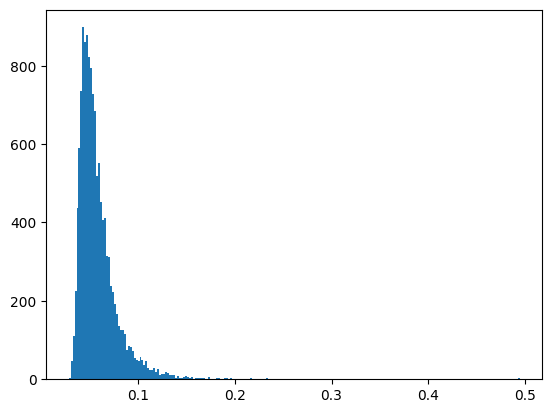

In [12]:
plt.hist(nsr.results['specificity'].dropna(), bins='auto');

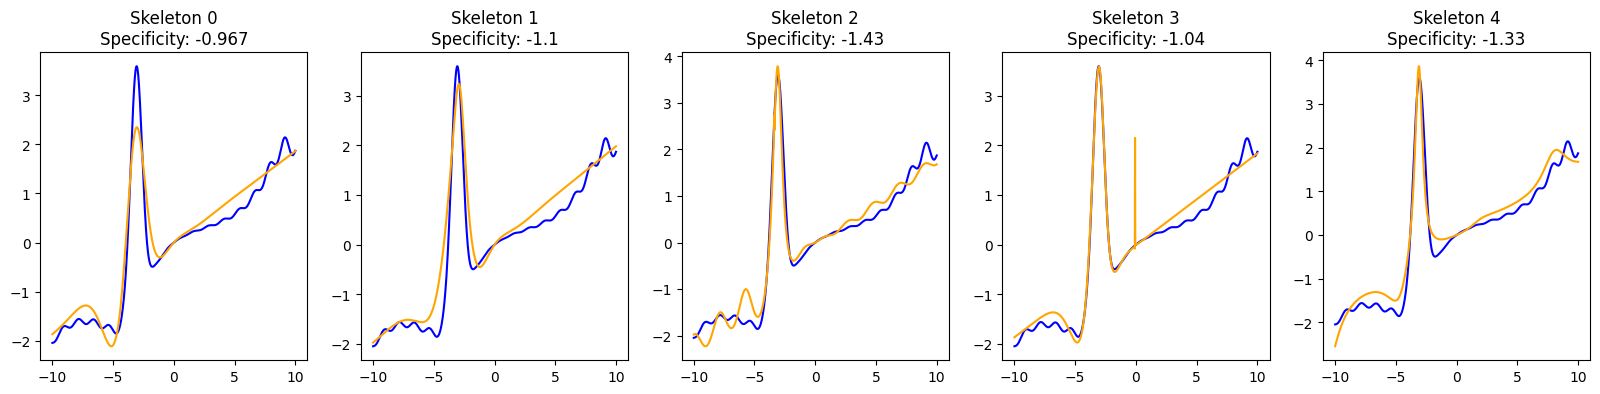

In [13]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i in range(5):
    axes[i].plot(x_linspace, y_linspace, label='True Function', color='blue')
    axes[i].plot(x_linspace, nsr.predict(x_linspace, i), label='Sampled Function', color='orange')
    axes[i].set_title(f"Skeleton {i}\nSpecificity: {np.log10(nsr.results.loc[i, 'specificity']):.3g}")

Skeleton 850 - Specificity: 0.495
Expression: ['*', '<constant>', '+', '<constant>', '*', '<constant>', 'tanh', '*', '<constant>', '-', 'sin', '*', '<constant>', 'x1', '+', '<constant>', '*', '<constant>', 'x1']

Skeleton 40 - Specificity: 0.493
Expression: ['<constant>']

Skeleton 7828 - Specificity: 0.317
Expression: ['/', 'x1', '-', '-', '/', 'cosh', '+', '-', 'pow1_3', 'x1', 'x1', '*', 'x1', 'cosh', '*', '<constant>', 'cos', '*', '<constant>', 'x1', '+', 'x1', 'pow1_3', 'pow4', 'x1', 'x1', '<constant>']

Skeleton 6445 - Specificity: 0.286
Expression: ['/', '*', '<constant>', 'x1', '-', 'x1', '/', 'x1', '/', 'sinh', '*', '<constant>', 'x1', '-', '/', 'x1', '+', '<constant>', '+', 'x1', 'cosh', 'tan', 'sin', '*', '<constant>', 'x1', '-', 'x1', '<constant>']

Skeleton 7979 - Specificity: 0.284
Expression: ['/', '*', '<constant>', '+', 'x1', '/', '-', '*', '<constant>', 'x1', '*', 'x1', '-', 'pow4', 'cos', 'pow2', 'x1', 'x1', '/', '+', 'x1', '*', '<constant>', 'cosh', '*', '<constant>'

/home/psaegert/Projects/simplipy/src/simplipy/operators.py:130: RuntimeWarning: invalid value encountered in power
  x = np.where(x < 0, -(-x) ** (1 / 3), x ** (1 / 3))


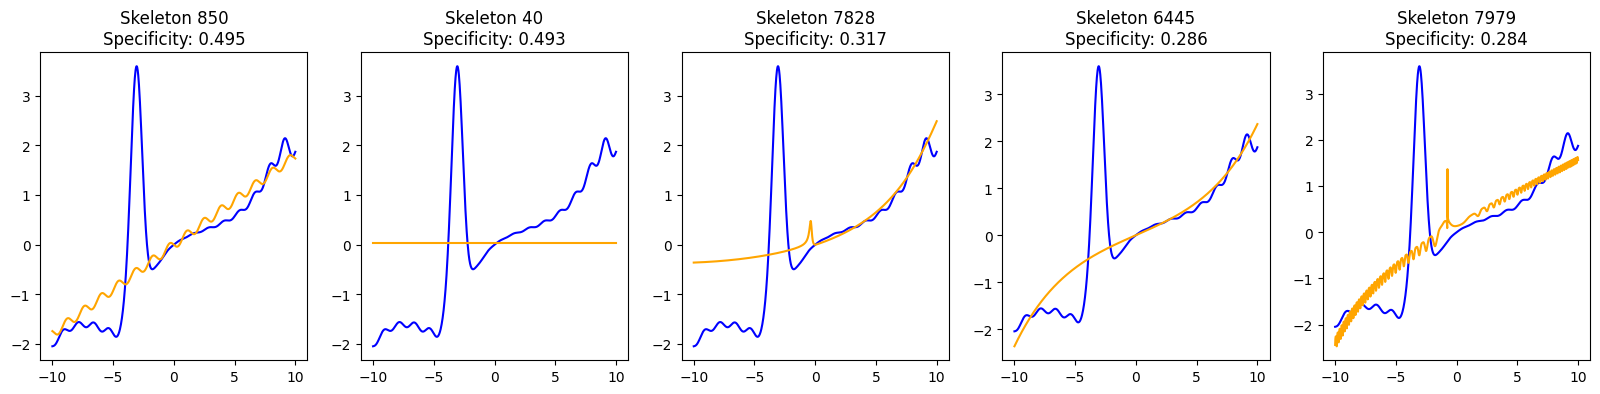

In [14]:
# Most specific expressions
most_specific = nsr.results.sort_values('specificity', ascending=False).head(5)
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i in range(5):
    print(f"Skeleton {most_specific.index[i]} - Specificity: {most_specific.iloc[i]['specificity']:.3f}")
    print(f"Expression: {most_specific.iloc[i]['expression']}")
    print()
    axes[i].plot(x_linspace, y_linspace, label='True Function', color='blue')
    axes[i].plot(x_linspace, nsr.predict(x_linspace, most_specific.index[i]), label='Sampled Function', color='orange')
    axes[i].set_title(f"Skeleton {most_specific.index[i]}\nSpecificity: {most_specific.iloc[i]['specificity']:.3f}")

Skeleton 2774 - Specificity: 0.028
Expression: ['/', '*', '<constant>', '*', 'x1', '-', '<constant>', '+', 'x1', '-', '*', '<constant>', 'sin', 'pow2', 'x1', '/', 'x1', '<constant>', '-', 'cos', 'x1', '+', '<constant>', 'x1']

Skeleton 11334 - Specificity: 0.028
Expression: ['/', '+', 'x1', '/', 'x1', '*', '<constant>', '/', '+', 'cos', 'x1', '/', 'x1', '+', '<constant>', 'x1', 'cos', '/', '-', 'cos', '*', '<constant>', 'x1', 'x1', 'pow1_5', 'x1', 'x1']

Skeleton 8589 - Specificity: 0.029
Expression: ['/', 'x1', '-', '+', '<constant>', '/', '*', '<constant>', 'x1', '-', '<constant>', '-', 'sin', '*', 'x1', 'sin', 'x1', 'x1', '*', '<constant>', 'cos', '-', 'x1', '<constant>']

Skeleton 6170 - Specificity: 0.030
Expression: ['*', 'sin', '+', '<constant>', '*', '<constant>', 'x1', '/', 'x1', '-', '+', '*', '<constant>', 'cos', 'x1', '*', '<constant>', 'pow1_5', 'neg', 'x1', '<constant>']

Skeleton 7368 - Specificity: 0.030
Expression: ['*', 'sin', '+', '<constant>', '/', 'x1', '+', 'x1', 

/home/psaegert/Projects/simplipy/src/simplipy/operators.py:173: RuntimeWarning: invalid value encountered in power
  x = np.where(x < 0, -(-x) ** (1 / 5), x ** (1 / 5))


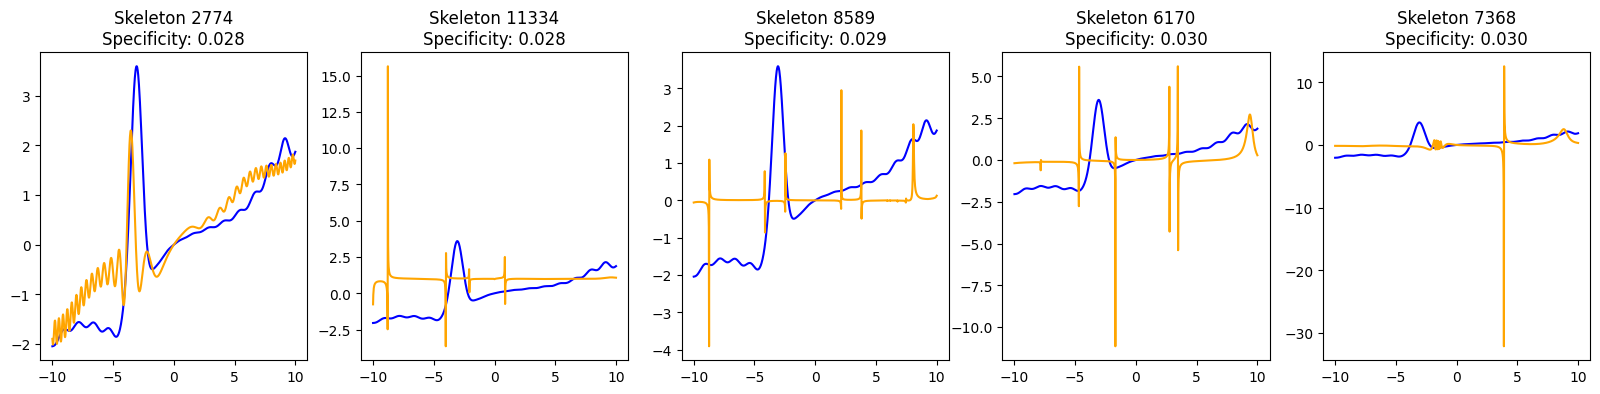

In [15]:
# Least specific expressions
least_specific = nsr.results.sort_values('specificity', ascending=True).head(5)
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i in range(5):
    print(f"Skeleton {least_specific.index[i]} - Specificity: {least_specific.iloc[i]['specificity']:.3f}")
    print(f"Expression: {least_specific.iloc[i]['expression']}")
    print()
    axes[i].plot(x_linspace, y_linspace, label='True Function', color='blue')
    axes[i].plot(x_linspace, nsr.predict(x_linspace, least_specific.index[i]), label='Sampled Function', color='orange')
    axes[i].set_title(f"Skeleton {least_specific.index[i]}\nSpecificity: {least_specific.iloc[i]['specificity']:.3f}")

In [55]:
nsr.results['log_fvu'] = np.log10(nsr.results['fvu'])

In [57]:
# Correlation coefficients of the specificity vs other metrics like score, log_prob, constant_count, etc.
for metric in ['log_fvu', 'score', 'log_prob', 'constant_count', 'complexity']:
    valid_mask = nsr.results['specificity'].notna() & nsr.results[metric].notna()

    if valid_mask.sum() > 0:
        corr = np.corrcoef(
            nsr.results.loc[valid_mask, 'specificity'],
            nsr.results.loc[valid_mask, metric]
        )[0, 1]
        print(f"{metric}: {corr:.3g}")

log_fvu: 0.00891
score: 0.0114
log_prob: -0.0633
constant_count: 0.0181
complexity: 0.0486


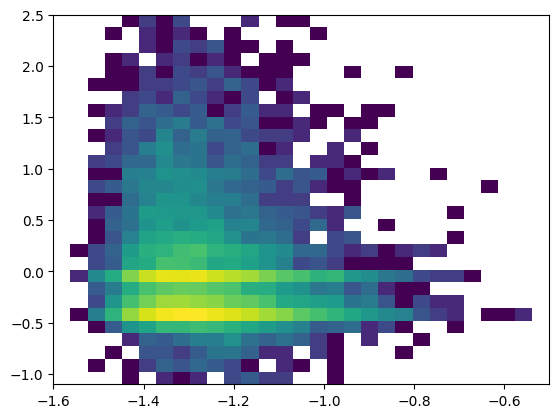

In [28]:
plt.hist2d(
    np.log10(nsr.results['specificity']),
    np.log10(nsr.results['fvu']),
    bins=(np.linspace(-1.6, -0.5, 30), np.linspace(-1.1, 2.5, 30)),
    norm='log'
);

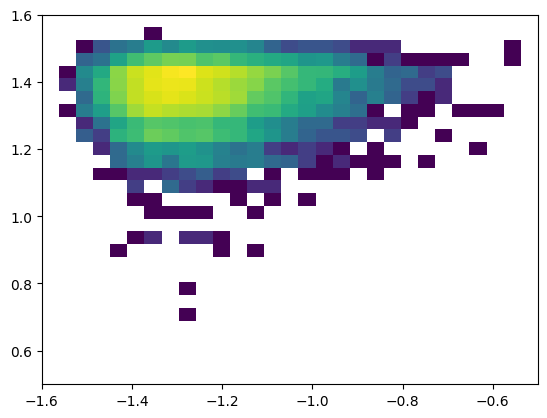

In [32]:
plt.hist2d(
    np.log10(nsr.results['specificity']),
    np.log10(nsr.results['complexity']),
    bins=(np.linspace(-1.6, -0.5, 30), np.linspace(0.5, 1.6, 30)),
    norm='log'
);

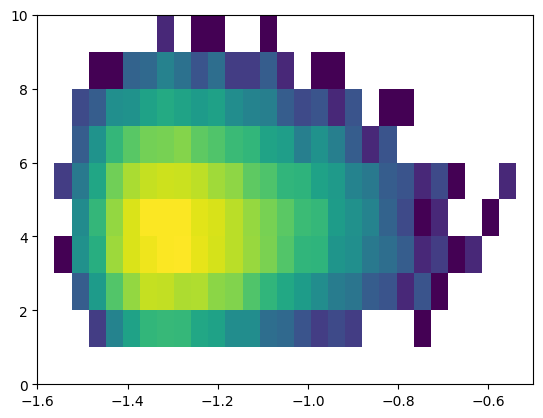

In [39]:
plt.hist2d(
    np.log10(nsr.results['specificity']),
    nsr.results['constant_count'],
    bins=(np.linspace(-1.6, -0.5, 30), np.linspace(0, 10, 11)),
    norm='log'
);

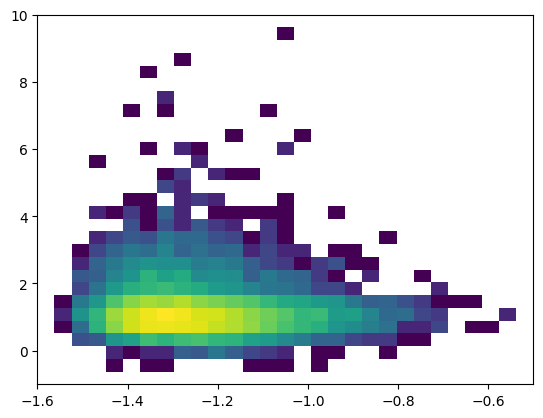

In [44]:
plt.hist2d(
    np.log10(nsr.results['specificity']),
    nsr.results['score'],
    bins=(np.linspace(-1.6, -0.5, 30), np.linspace(-1, 10, 30)),
    norm='log'
);

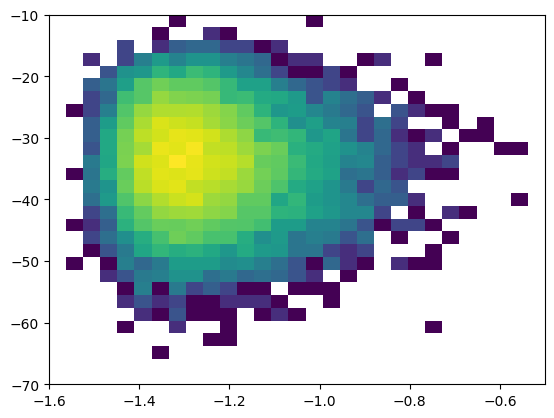

In [49]:
plt.hist2d(
    np.log10(nsr.results['specificity']),
    nsr.results['log_prob'],
    bins=(np.linspace(-1.6, -0.5, 30), np.linspace(-70, -10, 30)),
    norm='log'
);

## Embedding Diversity of Sampled Skeletons

For each unique skeleton in the results, we:
1. Build a `SkeletonPool` with the training prior (from the model config)
2. Compile the skeleton and sample N datasets (constants + support) from the prior
3. Encode each dataset with the model's SetTransformer encoder
4. Flatten all embeddings, run PCA, and plot the first M skeletons in different colors

In [9]:
from flash_ansr.expressions.skeleton_pool import SkeletonPool, NoValidSampleFoundError
from flash_ansr.expressions.compilation import codify
from flash_ansr.expressions.token_ops import identify_constants
from flash_ansr.utils.tensor_ops import pad_input_set
from flash_ansr.data import FlashANSRDataset
import torch.nn as nn
from tqdm import tqdm

In [10]:
# Load the skeleton pool from the training config to get the sampling priors
skeleton_pool_config_path = get_path('configs', MODEL, 'skeleton_pool_train.yaml')
skeleton_pool = SkeletonPool.from_config(skeleton_pool_config_path)
print(f"Skeleton pool variables: {skeleton_pool.variables[:5]}...")
print(f"Skeleton pool n_variables: {skeleton_pool.n_variables}")

Compiling Skeletons: 100%|██████████| 107/107 [00:00<00:00, 23282.35it/s]

Skeleton pool variables: ['x1', 'x2', 'x3', 'x4', 'x5']...
Skeleton pool n_variables: 17


In [ ]:
# --- Configuration ---
N = 256           # Number of sampled datasets per skeleton
M_compute = 128
N_SUPPORT = 1024  # Support points per sample
AE_STEPS = 512   # Number of autoencoder training steps
AE_BATCH = 128    # Batch size for autoencoder training
AE_DIM = 16        # Compressed embedding dimensionality
AE_LR = 1e-4

Embedding dim (seeds × d): 81920


Training autoencoder: 100%|██████████| 512/512 [02:46<00:00,  3.07it/s, loss=2.1956e-02]


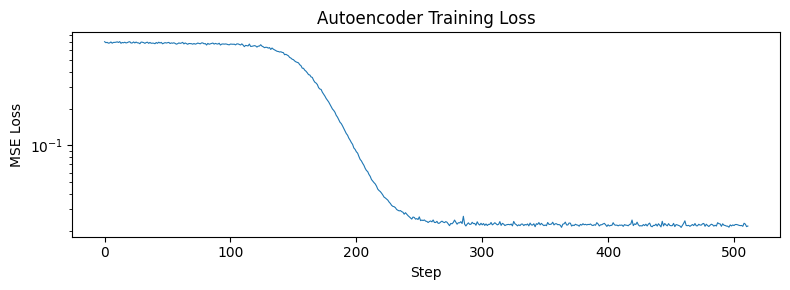

Final loss: 2.1956e-02


In [12]:
# --- Train a small autoencoder to compress SetTransformer embeddings ---
# Use FlashANSRDataset for fast batched data generation via multiprocessing,
# then encode with the frozen model and train: (seeds * d) -> AE_DIM -> (seeds * d)

simplipy_engine = nsr.simplipy_engine
flash_model = nsr.flash_ansr_model
n_variables = nsr.n_variables
flash_model.eval()

# Build a dataset from the model's training config for fast batch generation
ae_dataset = FlashANSRDataset(
    skeleton_pool=skeleton_pool,
    tokenizer=nsr.flash_ansr_model.tokenizer,
    padding='zero',
)

# Determine embedding dim by doing one forward pass
for probe_batch in ae_dataset.iterate(steps=1, batch_size=1, n_support=N_SUPPORT):
    data_probe = torch.cat([probe_batch['x_tensors'], probe_batch['y_tensors']], dim=-1).to(device)
    with torch.no_grad():
        mem_probe = flash_model._create_memory(data_probe, data_attn_mask=probe_batch['data_attn_mask'].to(device))
    emb_dim = mem_probe.view(1, -1).shape[1]
    break
print(f"Embedding dim (seeds × d): {emb_dim}")

# Define autoencoder
class EmbeddingAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()
        mid = max(latent_dim * 4, 128)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, mid),
            nn.GELU(),
            nn.Linear(mid, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, mid),
            nn.GELU(),
            nn.Linear(mid, input_dim),
        )
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z
    def encode(self, x):
        return self.encoder(x)

autoencoder = EmbeddingAutoencoder(emb_dim, AE_DIM).to(device)
ae_optimizer = torch.optim.AdamW(autoencoder.parameters(), lr=AE_LR)

# Training loop — iterate full batches from FlashANSRDataset
ae_losses = []
pbar = tqdm(
    ae_dataset.iterate(steps=AE_STEPS, batch_size=AE_BATCH, n_support=N_SUPPORT),
    total=AE_STEPS,
    desc="Training autoencoder",
)
for step, batch in enumerate(pbar):
    data_tensor = torch.cat([batch['x_tensors'], batch['y_tensors']], dim=-1).to(device)
    mask = batch['data_attn_mask'].to(device)

    with torch.no_grad():
        memory = flash_model._create_memory(data_tensor, data_attn_mask=mask)  # (B, seeds, d)
        embeddings = memory.view(memory.shape[0], -1)  # (B, seeds*d)

    recon, _ = autoencoder(embeddings)
    loss = nn.functional.mse_loss(recon, embeddings)

    ae_optimizer.zero_grad()
    loss.backward()
    ae_optimizer.step()

    ae_losses.append(loss.item())
    pbar.set_postfix(loss=f"{loss.item():.4e}")

autoencoder.eval()

# Plot training curve
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(ae_losses, linewidth=0.8)
ax.set_xlabel('Step')
ax.set_ylabel('MSE Loss')
ax.set_title('Autoencoder Training Loss')
ax.set_yscale('log')
plt.tight_layout()
plt.show()
print(f"Final loss: {ae_losses[-1]:.4e}")

In [13]:
# Pick the first M unique skeletons from the results
unique_expressions = nsr.results['expression'].apply(tuple).unique()
selected_skeletons = [list(expr) for expr in unique_expressions[:M_compute]]

for i, sk in enumerate(selected_skeletons[:10]):
    print(f"Skeleton {i}: {' '.join(sk)}")

Skeleton 0: / x1 - <constant> / * <constant> x1 - * <constant> + x1 cos * <constant> x1 + <constant> x1
Skeleton 1: / - neg x1 / pow2 x1 cosh + x1 - <constant> exp cos x1 <constant>
Skeleton 2: / - x1 * <constant> x1 - - <constant> / x1 - <constant> - cos + <constant> * <constant> x1 x1 sin * <constant> x1
Skeleton 3: * x1 + <constant> / <constant> - / cos * <constant> x1 - * <constant> x1 <constant> <constant>
Skeleton 4: / x1 - / <constant> sin cos asinh * <constant> * x1 - x1 cos * <constant> x1 <constant>
Skeleton 5: * x1 cos pow1_3 - / x1 + x1 / + <constant> cos x1 <constant> <constant>
Skeleton 6: * pow2 x1 tanh + / <constant> x1 / sin + x1 cos x1 cosh + <constant> x1
Skeleton 7: / x1 + <constant> / - cos * <constant> x1 <constant> / <constant> - <constant> x1
Skeleton 8: / + x1 / pow2 x1 cosh + <constant> - x1 * <constant> pow2 x1 <constant>
Skeleton 9: / x1 - <constant> - sin - x1 <constant> / * <constant> pow2 x1 + <constant> x1


In [14]:
# For each skeleton, compile it and sample N datasets, then encode + compress them
model = nsr.flash_ansr_model

all_embeddings = []    # Compressed 2D embeddings
skeleton_labels = []   # Which skeleton each embedding belongs to

model.eval()
autoencoder.eval()
with torch.no_grad():
    for skel_idx, skeleton_tokens in enumerate(tqdm(selected_skeletons)):        
        # Compile the skeleton into executable code
        executable = simplipy_engine.operators_to_realizations(list(skeleton_tokens))
        expr_with_constants, constants = identify_constants(executable, inplace=True)
        code_string = simplipy_engine.prefix_to_infix(expr_with_constants, realization=True)
        code = codify(code_string, skeleton_pool.variables + constants)
        
        n_constants = len(constants)
        
        successes = 0
        attempts = 0
        while successes < N:
            attempts += 1
            if attempts > N * 10:
                print(f"  Warning: only got {successes}/{N} samples after {attempts} attempts")
                break
            try:
                x_support, y_support, literals = skeleton_pool.sample_data(
                    code=code,
                    n_constants=n_constants,
                    n_support=N_SUPPORT,
                )
            except Exception:
                continue
            
            # Prepare the data tensor exactly as in FlashANSR.fit
            X_t = torch.tensor(x_support, dtype=torch.float32, device=device)
            y_t = torch.tensor(y_support, dtype=torch.float32, device=device)
            
            X_t = pad_input_set(X_t, n_variables)
            data_tensor = torch.cat([X_t, y_t], dim=-1)
            
            # Encode with the SetTransformer, then compress with autoencoder
            memory = model._create_memory(data_tensor)        # (1, n_seeds, encoder_dim)
            compressed = autoencoder.encode(memory.flatten())  # (AE_DIM,)
            
            all_embeddings.append(compressed.cpu().numpy())
            skeleton_labels.append(skel_idx)
            successes += 1

all_embeddings = np.array(all_embeddings)   # (total_samples, AE_DIM)
skeleton_labels = np.array(skeleton_labels)
print(f"\nCompressed embeddings: {all_embeddings.shape}")

100%|██████████| 128/128 [03:54<00:00,  1.83s/it]


Compressed embeddings: (32768, 16)


In [15]:
# Embeddings are already 2D from the autoencoder — no PCA needed
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(all_embeddings)
print(f"Explained variance by PCA components: {pca.explained_variance_ratio_}")

Explained variance by PCA components: [9.9973756e-01 6.5005697e-05]


In [ ]:
M_plot = 8

/tmp/ipykernel_30034/2351364786.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', M_plot)


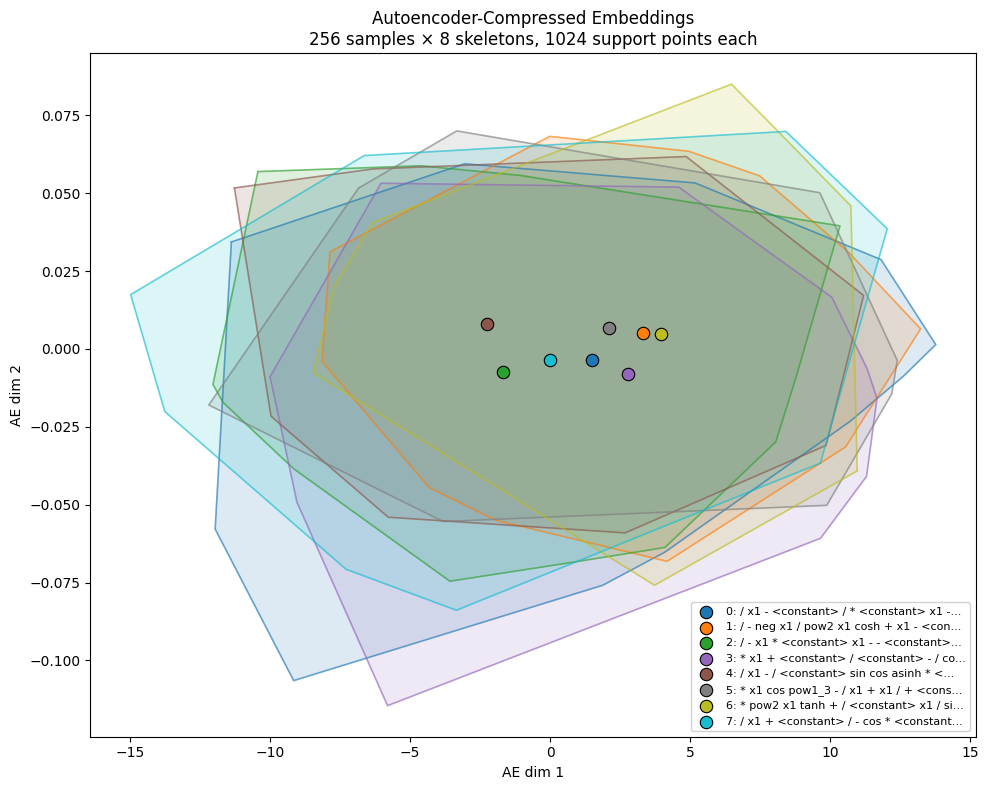

In [16]:
from scipy.spatial import ConvexHull

fig, ax = plt.subplots(figsize=(10, 8))

cmap = plt.cm.get_cmap('tab10', M_plot)
for skel_idx in range(M_plot):
    mask = skeleton_labels == skel_idx
    if not mask.any():
        continue
    pts = embeddings_2d[mask]
    color = cmap(skel_idx)
    label = ' '.join(selected_skeletons[skel_idx])
    if len(label) > 40:
        label = label[:37] + '...'
    label = f'{skel_idx}: {label}'

    # Draw filled convex hull
    if pts.shape[0] >= 3:
        hull = ConvexHull(pts)
        hull_pts = pts[hull.vertices]
        hull_pts = np.vstack([hull_pts, hull_pts[0]])  # close the polygon
        ax.fill(hull_pts[:, 0], hull_pts[:, 1], color=color, alpha=0.15)
        ax.plot(hull_pts[:, 0], hull_pts[:, 1], color=color, linewidth=1.2, alpha=0.6)

    # Plot centroid marker
    centroid = pts.mean(axis=0)
    ax.scatter(centroid[0], centroid[1], c=[color], marker='o', s=80,
               edgecolors='k', linewidths=0.8, zorder=5, label=label)

ax.set_xlabel('AE dim 1')
ax.set_ylabel('AE dim 2')
ax.set_title(f'Autoencoder-Compressed Embeddings\n{N} samples × {M_plot} skeletons, {N_SUPPORT} support points each')
ax.legend(fontsize=8, loc='best', framealpha=0.9)
plt.tight_layout()
plt.show()

In [17]:
n_skeletons = M_plot

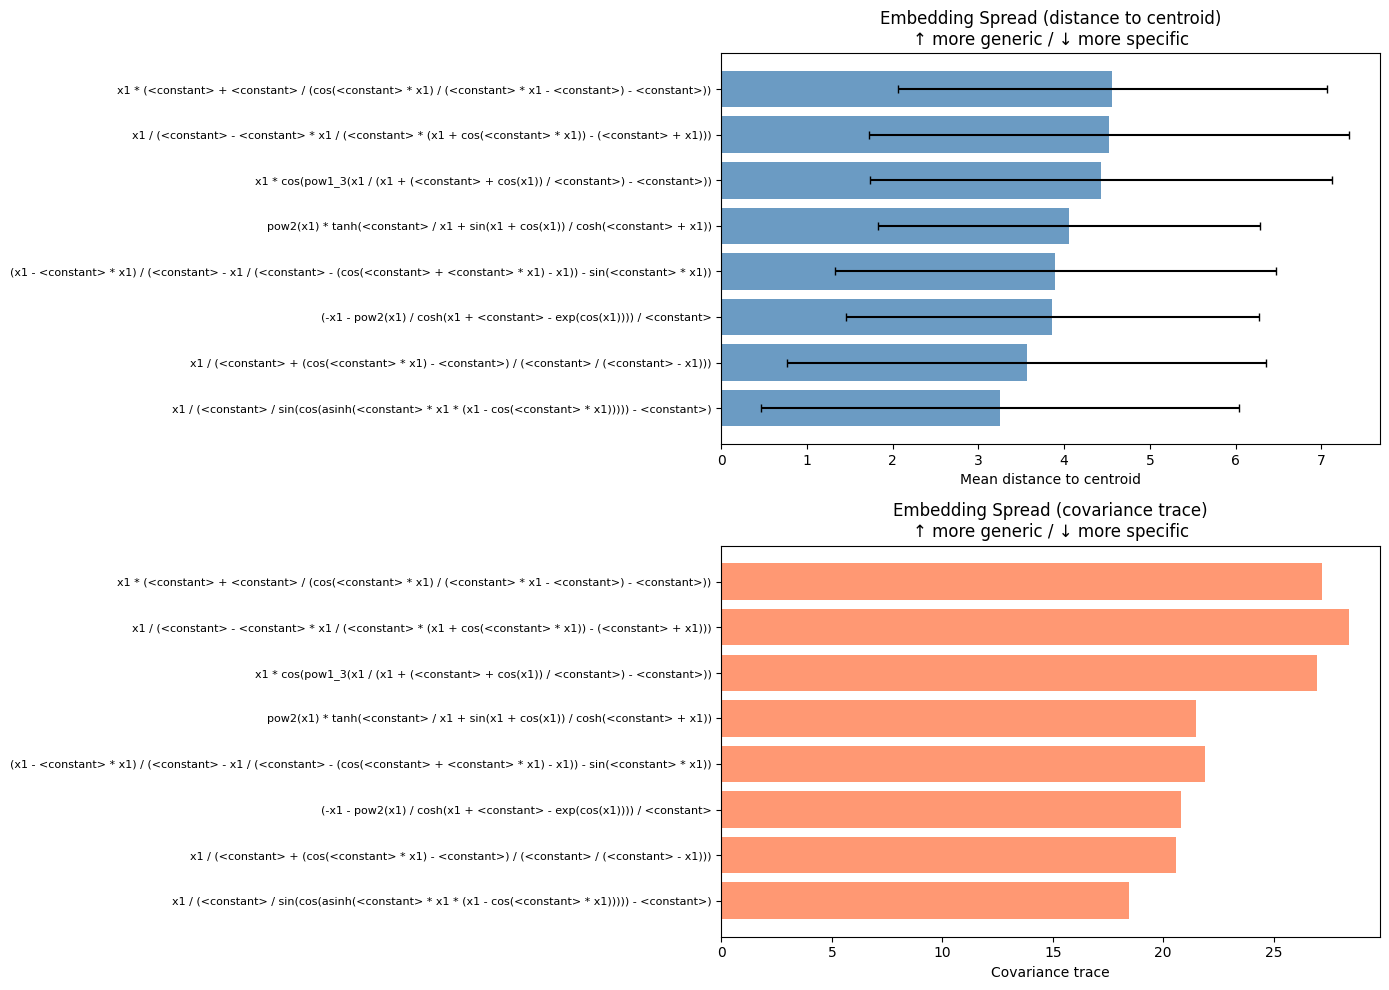

 skeleton                                                                                                                       label  mean_dist  cov_trace  n_samples
        3                       x1 * (<constant> + <constant> / (cos(<constant> * x1) / (<constant> * x1 - <constant>) - <constant>))   4.560084  27.167243        256
        0                        x1 / (<constant> - <constant> * x1 / (<constant> * (x1 + cos(<constant> * x1)) - (<constant> + x1)))   4.523831  28.392082        256
        5                                              x1 * cos(pow1_3(x1 / (x1 + (<constant> + cos(x1)) / <constant>) - <constant>))   4.428717  26.972050        256
        6                                                pow2(x1) * tanh(<constant> / x1 + sin(x1 + cos(x1)) / cosh(<constant> + x1))   4.052868  21.478921        256
        2 (x1 - <constant> * x1) / (<constant> - x1 / (<constant> - (cos(<constant> + <constant> * x1) - x1)) - sin(<constant> * x1))   3.897552  21.901796        25

: 

In [ ]:
# --- 2) Per-skeleton spread: mean distance to centroid & covariance trace ---
import pandas as pd

spread_stats = []
for skel_idx in range(n_skeletons):
    emb = all_embeddings[skeleton_labels == skel_idx]
    centroid = emb.mean(axis=0)
    dists_to_centroid = np.linalg.norm(emb - centroid, axis=1)
    cov_trace = np.trace(np.cov(emb, rowvar=False))
    label = simplipy_engine.prefix_to_infix(selected_skeletons[skel_idx])
    # if len(label) > 40:
    #     label = label[:37] + '...'
    spread_stats.append({
        'skeleton': skel_idx,
        'label': label,
        'mean_dist': dists_to_centroid.mean(),
        'std_dist': dists_to_centroid.std(),
        'max_dist': dists_to_centroid.max(),
        'cov_trace': cov_trace,
        'n_samples': len(emb),
    })

spread_df = pd.DataFrame(spread_stats).sort_values('mean_dist', ascending=False)

# Bar chart
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Left: mean distance to centroid
ax = axes[0]
ax.barh(range(len(spread_df)), spread_df['mean_dist'], xerr=spread_df['std_dist'],
        color='steelblue', alpha=0.8, capsize=3)
ax.set_yticks(range(len(spread_df)))
ax.set_yticklabels([f"{r['label']}" for _, r in spread_df.iterrows()], fontsize=8)
ax.set_xlabel('Mean distance to centroid')
ax.set_title('Embedding Spread (distance to centroid)\n↑ more generic / ↓ more specific')
ax.invert_yaxis()

# Right: covariance trace
ax = axes[1]
ax.barh(range(len(spread_df)), spread_df['cov_trace'], color='coral', alpha=0.8)
ax.set_yticks(range(len(spread_df)))
ax.set_yticklabels([f"{r['label']}" for _, r in spread_df.iterrows()], fontsize=8)
ax.set_xlabel('Covariance trace')
ax.set_title('Embedding Spread (covariance trace)\n↑ more generic / ↓ more specific')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

# Print table
print(spread_df[['skeleton', 'label', 'mean_dist', 'cov_trace', 'n_samples']].to_string(index=False))

Computing MMD matrix:   0%|          | 0/28 [00:00<?, ?it/s]

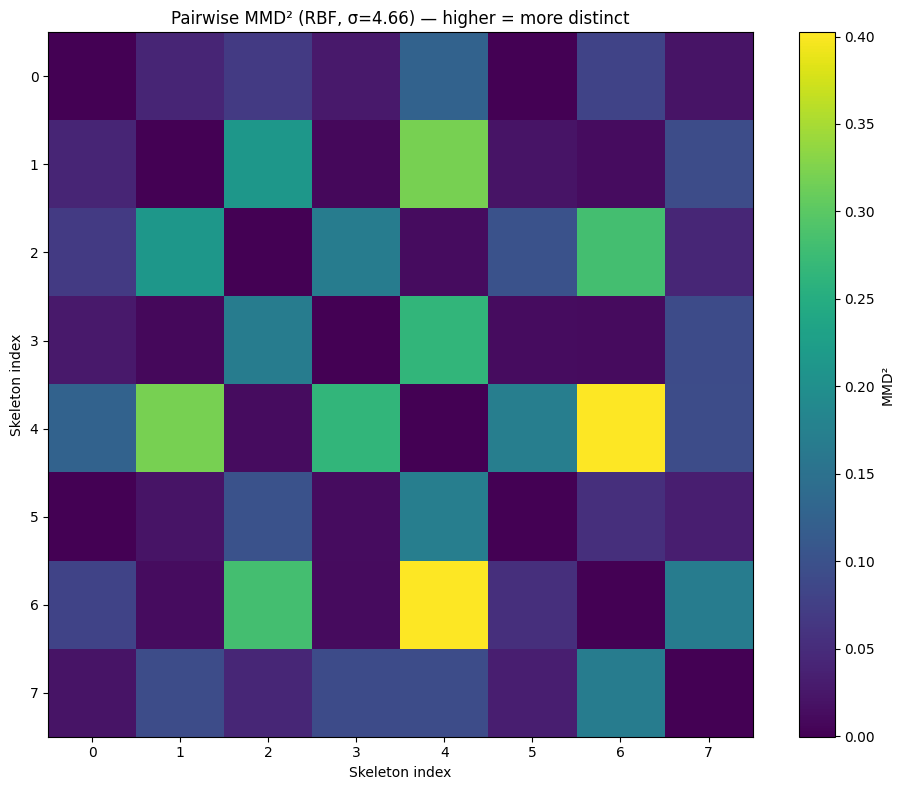

MMD² — mean: 0.1050,  median: 0.0742,  min: -0.0004,  max: 0.4024


In [19]:
from scipy.spatial.distance import cdist

# --- 1) Pairwise similarity: MMD with RBF kernel ---
# Median heuristic for RBF bandwidth (estimated from a subsample to avoid O(n²) blowup)
rng = np.random.default_rng(42)
subsample_size = min(2000, len(embeddings_2d))
subsample_idx = rng.choice(len(embeddings_2d), size=subsample_size, replace=False)
sub_dists = cdist(embeddings_2d[subsample_idx], embeddings_2d[subsample_idx], metric='euclidean')
sigma = np.median(sub_dists[np.triu_indices_from(sub_dists, k=1)])

def rbf_mmd2(X, Y, sigma):
    """Unbiased MMD² estimate with RBF kernel."""
    gamma = 1.0 / (2 * sigma ** 2)
    Kxx = np.exp(-gamma * cdist(X, X, 'sqeuclidean'))
    Kyy = np.exp(-gamma * cdist(Y, Y, 'sqeuclidean'))
    Kxy = np.exp(-gamma * cdist(X, Y, 'sqeuclidean'))
    nx, ny = len(X), len(Y)
    mmd2 = (Kxx.sum() - np.trace(Kxx)) / (nx * (nx - 1)) \
          + (Kyy.sum() - np.trace(Kyy)) / (ny * (ny - 1)) \
          - 2 * Kxy.mean()
    return mmd2

mmd_matrix = np.zeros((n_skeletons, n_skeletons))
pbar = tqdm(total=n_skeletons * (n_skeletons - 1) // 2, desc='Computing MMD matrix')
for i in range(n_skeletons):
    Xi = embeddings_2d[skeleton_labels == i]
    for j in range(i + 1, n_skeletons):
        Xj = embeddings_2d[skeleton_labels == j]
        mmd2 = rbf_mmd2(Xi, Xj, sigma)
        pbar.update(1)
        mmd_matrix[i, j] = mmd2
        mmd_matrix[j, i] = mmd2

# Plot heatmap
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(mmd_matrix, cmap='viridis')
ax.set_xticks(range(n_skeletons))
ax.set_yticks(range(n_skeletons))
ax.set_xlabel('Skeleton index')
ax.set_ylabel('Skeleton index')
ax.set_title(f'Pairwise MMD² (RBF, σ={sigma:.2f}) — higher = more distinct')
plt.colorbar(im, ax=ax, label='MMD²')
plt.tight_layout()
plt.show()

# Summary stat
triu_vals = mmd_matrix[np.triu_indices_from(mmd_matrix, k=1)]
print(f"MMD² — mean: {triu_vals.mean():.4f},  median: {np.median(triu_vals):.4f},  "
      f"min: {triu_vals.min():.4f},  max: {triu_vals.max():.4f}")